First 5 Rows
   trip_id  driver_id  rider_id           city  pickup_lat  pickup_lng  \
0        1       8270     10683  San Francisco   37.170931  -77.586479   
1        2       1860     44743         Boston   38.898127 -108.582977   
2        3       6390     75839  San Francisco   38.814571  -89.942603   
3        4       6191     22189       New York   37.295906  -75.328844   
4        5       6734     61104        Seattle   38.972395 -121.482913   

    drop_lat    drop_lng  distance_km  fare_amount     status payment_method  \
0  37.173652  -77.619934         2.97        10.71  Completed         Wallet   
1  38.937464 -108.558727         8.43        22.41  Completed            UPI   
2  38.821702  -89.896435         5.46        12.91  Completed           Cash   
3  37.301375  -75.317488         6.61        15.70  Completed         Wallet   
4  38.992088 -121.467904        10.50        19.15  Completed         Wallet   

           pickup_time                      drop_time  
0  20

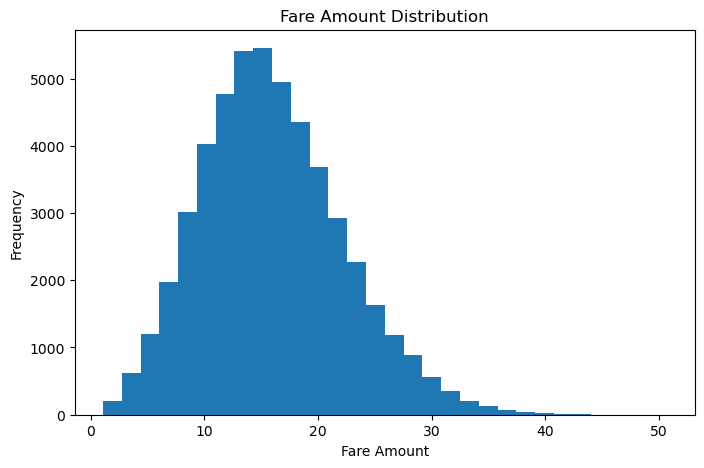

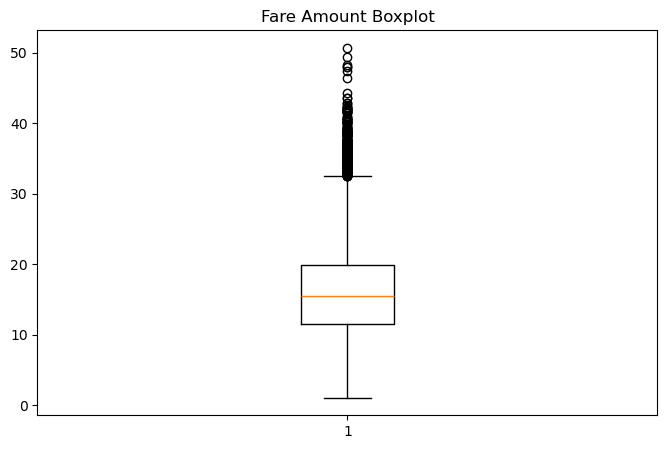


Outlier Detection Using IQR
Number of Outliers: 495

EDA Process Completed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uber="C:\\Users\\ACER\\Downloads\\uber_trips_dataset_50k.csv"
df = pd.read_csv(uber)

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nStatistical Summary")
print(df.describe())

print("\nData Types")
print(df.dtypes)

if 'pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

    df['year'] = df['pickup_datetime'].dt.year
    df['month'] = df['pickup_datetime'].dt.month
    df['day'] = df['pickup_datetime'].dt.day
    df['hour'] = df['pickup_datetime'].dt.hour

    print("\nDate Time Columns Added")
    print(df[['year','month','day','hour']].head())

numeric_columns = df.select_dtypes(include=np.number)

print("\nCorrelation Matrix")
print(numeric_columns.corr())

plt.figure(figsize=(8,5))
plt.hist(df['fare_amount'], bins=30)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df['fare_amount'])
plt.title("Fare Amount Boxplot")
plt.show()

if 'passenger_count' in df.columns:
    passenger_counts = df['passenger_count'].value_counts()

    plt.figure(figsize=(8,5))
    plt.bar(passenger_counts.index, passenger_counts.values)
    plt.title("Passenger Count")
    plt.xlabel("Passengers")
    plt.ylabel("Count")
    plt.show()

if 'hour' in df.columns:
    hourly_rides = df['hour'].value_counts().sort_index()

    plt.figure(figsize=(10,5))
    plt.plot(hourly_rides.index, hourly_rides.values, marker='o')
    plt.title("Trips by Hour")
    plt.xlabel("Hour")
    plt.ylabel("Number of Trips")
    plt.grid()
    plt.show()

print("\nOutlier Detection Using IQR")

Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['fare_amount'] < lower_limit) | (df['fare_amount'] > upper_limit)]

print("Number of Outliers:", outliers.shape[0])

print("\nEDA Process Completed")